In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from tqdm import tqdm

In [54]:
# functions

def half_mass_radius(radii, masses):
    idr = np.argsort(radii)
    r_sorted = radii[idr]
    m_sorted = masses[idr]    
    m_cum = np.cumsum(m_sorted)
    m_half = 0.5 * np.sum(masses)    
    i = np.searchsorted(m_cum, m_half)
    return r_sorted[i]

def radius(pos, centre):
    return np.sqrt((pos[:,0]-centre[0])**2 + (pos[:,1]-centre[1])**2 + (pos[:,2]-centre[2])**2)

def velocity(vel):
    return np.sqrt((vel[:,0])**2 + (vel[:,1])**2 + (vel[:,2])**2)

In [55]:
s1_pos = []
s1_vel = []
s1_mbp = []
s1_mass = []
r1s = []
v1s = []
HMRs = []

g1_pos = []
g1_vel = []
g1_mass = []
r1g = []
v1g = []
HMRg = []

In [ ]:
secondary = True

for n in tqdm(range(100)):
    g1 = h5py.File('GettingStarted/particles_snap_0'+f"{n:02d}"+'_galID341536_Primary.hdf5', 'r')
    #########  STARS #########
    s1_mbp.append(g1['Star']['MostBoundParticle'][:])
    s1_mass.append(g1['Star']['Mass'][:])
    # position & radii
    s1_pos.append(g1['Star']['Position'][:])
    r1s.append(radius(s1_pos[-1], s1_mbp[-1]))
    # velocities
    s1_vel.append(g1['Star']['Velocity'][:])
    v1s.append(velocity(s1_vel[-1]))
    # half-mass radius
    HMRs.append( half_mass_radius(r1s[-1], s1_mass[-1][:]) )
    
    #########  GAS #########
    g1_mass.append(g1['Gas']['Mass'][:])
    # position & radii
    g1_pos.append(g1['Gas']['Position'][:])
    r1g.append(radius(g1_pos[-1], s1_mbp[-1]))
    # velocities
    g1_vel.append(g1['Gas']['Velocity'][:])
    v1g.append(velocity(g1_vel[-1]))
    # half-mass radius
    HMRg.append( half_mass_radius(r1g[-1], g1_mass[-1][:]) )

 
    if (n>0)&(n<50)&(secondary==True):
        g2 = h5py.File('GettingStarted/particles_snap_0'+f"{n:02d}"+'_galID341536_Secondary.hdf5', 'r')

g1.keys()

 95%|█████████████████████████████████████████████████████████████████████████████▉    | 95/100 [01:16<00:03,  1.41it/s]

In [4]:
for name in g1['Header'].attrs.keys():
    print(name, '\t', g1['Header'].attrs[name])

Accretion_Units 	 Msun/yr
Masses_Units 	 Msun
Pos_Units 	 kpc (proper-physical)
Potential 	 (km/s)^2
Vel_Units 	 km/s


In [5]:
for name in g1['BlackHole'].keys():
    print(name, '\t', g1['BlackHole'][name][:])

BH_Density 	 [104969.195]
BH_Mass 	 [1.399248e+08]
BH_Mdot 	 [3.9989867e-05]
BH_MdotBondi 	 [3.9989864e-05]
BH_MdotEddington 	 [1.5518297]
Mass 	 [1.399248e+08]
ParticleIDs 	 [114734816996]
Position 	 [[12039.58064209 37506.48265626 42152.11920013]]
Potential 	 [-275354.40625]
Velocity 	 [[ -21.4461956     4.28502131 -289.47714233]]


In [6]:
print(g1['Gas'].keys())
print(g1['Star'].keys())

<KeysViewHDF5 ['Mass', 'ParticleID', 'Position', 'StarFormationRate', 'Velocity']>
<KeysViewHDF5 ['Mass', 'MostBoundParticle', 'MostBoundParticleVel', 'ParticleID', 'Position', 'Potential', 'StarFormationTime', 'Velocity']>


In [3]:
ns = []
ng = []
for i in range(100):
    ns.append(len(s1_pos[i]))
    ng.append(len(g1_pos[i]))

plt.figure(figsize=(5,3))
plt.plot(ns, label='stars')
plt.plot(ng, c='orange', label='gas')
plt.xlabel('snapshot')
plt.ylabel('# particles')
plt.grid(ls='dotted')
plt.legend()
plt.show()

NameError: name 's1_pos' is not defined

Text(0, 0.5, 'gas half-mass radius [kpc]')

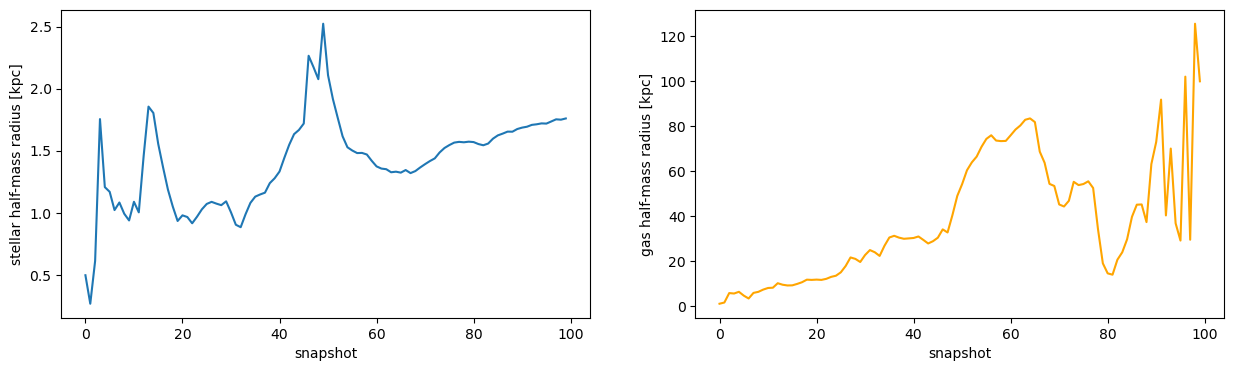

In [65]:
fig = plt.figure(figsize=(15,4))
ax = fig.add_subplot(121)
ax.plot(HMRs)
plt.xlabel('snapshot')
plt.ylabel('stellar half-mass radius [kpc]')
ax = fig.add_subplot(122)
ax.plot(HMRg, c='orange')
plt.xlabel('snapshot')
plt.ylabel('gas half-mass radius [kpc]')